In [2]:
# Test to load one pickle file
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from lameg.laminar import compute_csd
from lameg.viz import plot_csd

In [3]:
filepath = '/home/sgailhard/Documents/laminar_meg/laminar_csd_method/simulations/2_double_dipole/2_consecutive/cluster/sim_2_consec_sources'
#filename = 'vx27692_2_consec_sources_tmp_dist25win_size25.pickle'
filename = 'vx27692_2_consec_sources_tmp_dist10win_size10.pickle'

with open(os.path.join(filepath, filename), 'rb') as f:
    data = pickle.load(f)

In [4]:
data

{'sim_vertex': 27692,
 'n_layers': 11,
 'sim_layers': [(1, 9), (3, 7)],
 'patch_size': 5,
 'err_level': 0,
 'sim_patch_size': 5,
 'n_temp_modes_ebb': 4,
 'n_spatial_modes': 'auto',
 'hann_windowing_ebb': False,
 'snr': 0,
 'dipole_moment': [10, 10],
 'sim_signal': array([[0.00481723, 0.00597602, 0.00738068, 0.00907509, 0.011109  ,
         0.01353844, 0.01642602, 0.01984109, 0.02385991, 0.0285655 ,
         0.03404745, 0.04040148, 0.04772871, 0.05613476, 0.06572853,
         0.07662063, 0.08892162, 0.10273981, 0.11817892, 0.13533528,
         0.15429501, 0.17513079, 0.1978987 , 0.22263487, 0.24935221,
         0.2780373 , 0.30864746, 0.3411082 , 0.3753111 , 0.41111229,
         0.44833156, 0.48675226, 0.52612196, 0.56615415, 0.60653066,
         0.64690518, 0.68690756, 0.72614904, 0.76422817, 0.8007374 ,
         0.83527021, 0.86742847, 0.89683006, 0.92311635, 0.94595947,
         0.96506912, 0.98019867, 0.9911505 , 0.99778025, 1.        ,
         0.99778025, 0.9911505 , 0.98019867, 0

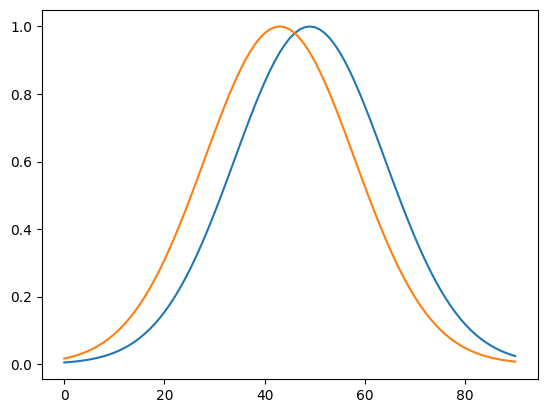

In [5]:
# plot the sim signal
for idx in range(len(data["sim_signal"])):
    plt.plot(data["sim_signal"][idx])

In [6]:
data.keys()

dict_keys(['sim_vertex', 'n_layers', 'sim_layers', 'patch_size', 'err_level', 'sim_patch_size', 'n_temp_modes_ebb', 'n_spatial_modes', 'hann_windowing_ebb', 'snr', 'dipole_moment', 'sim_signal', 'win_size', 'sfreq', 'thickness', 'time', 'ts_ebb_layer', 'ts_slidwd_ebb_layer', 'fs_slidwd', 'fid_coords'])

In [7]:
n_layers = data["n_layers"]

In [8]:
# get the relative free energy 
fs_matrix = data['fs_slidwd']      # (n_rows, 11, 11)
relativeFs = np.array([
        fs_matrix[sim_idx, :] - fs_matrix[sim_idx, :].min()
        for sim_idx in range(fs_matrix.shape[0])
    ])

In [9]:
relativeFs.shape #(n_sim, n_layers)

(2, 11, 91)

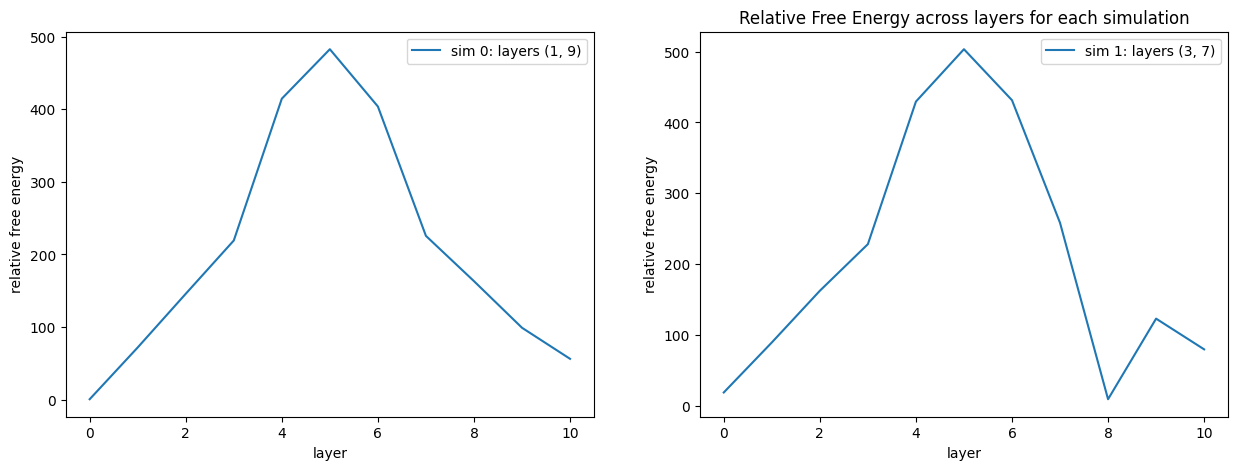

In [10]:
fig, ax = plt.subplots(1, relativeFs.shape[0], figsize=(15, 5))
for i in range(relativeFs.shape[0]):
    ax[i].plot(relativeFs[i, :, 45], label=f'sim {i}: layers {data["sim_layers"][i]}')
    ax[i].set_xlabel('layer')
    ax[i].set_ylabel('relative free energy')
    ax[i].legend()
plt.title('Relative Free Energy across layers for each simulation')
plt.show()

In [11]:
# get the ebb matrix
sfreq = data['sfreq']
thickness = data['thickness']
ebb_matrix = data['ts_ebb_layer']      # (n_sim, n_layers)
csd_ebb = np.array([
        compute_csd(ebb_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 1.4677992676220675e-06


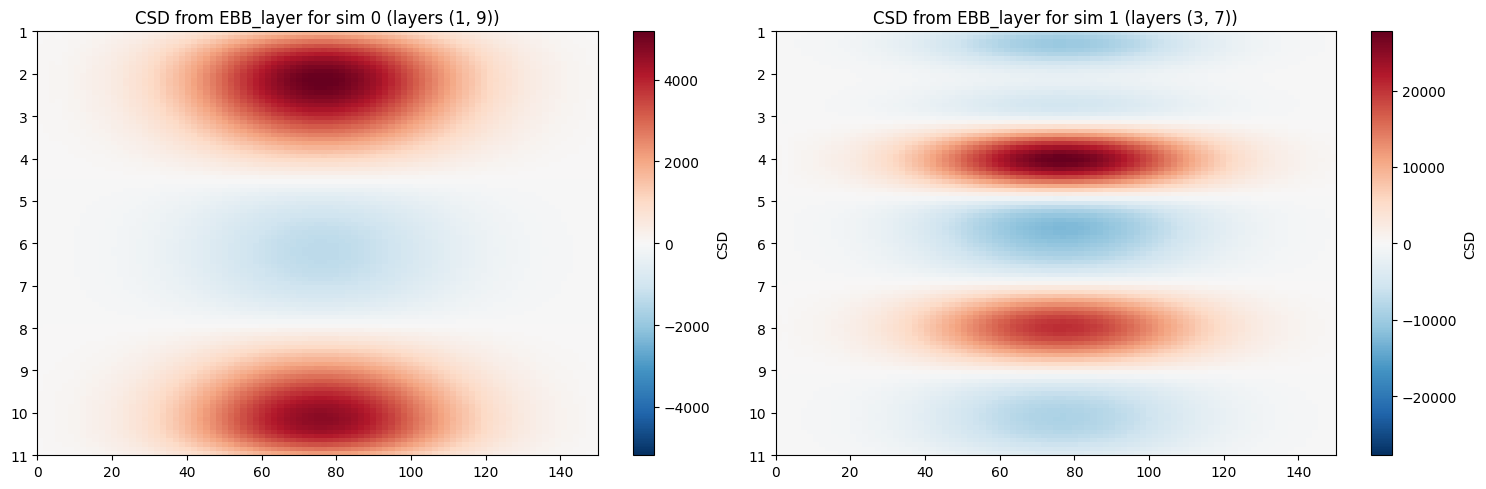

In [12]:
fig, ax = plt.subplots(1, csd_ebb.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb.shape[0]):
    plot_csd(csd_ebb[sim_idx, :], data["time"], ax[sim_idx])
    ax[sim_idx].set_title(f'CSD from EBB_layer for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')

In [13]:
# get the ebb_layer matrix
ebb_layer_matrix = data['ts_slidwd_ebb_layer']      # (n_sim, n_layers)
csd_ebb_layer = np.array([
        compute_csd(ebb_layer_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_layer_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.0011006941712522092
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01


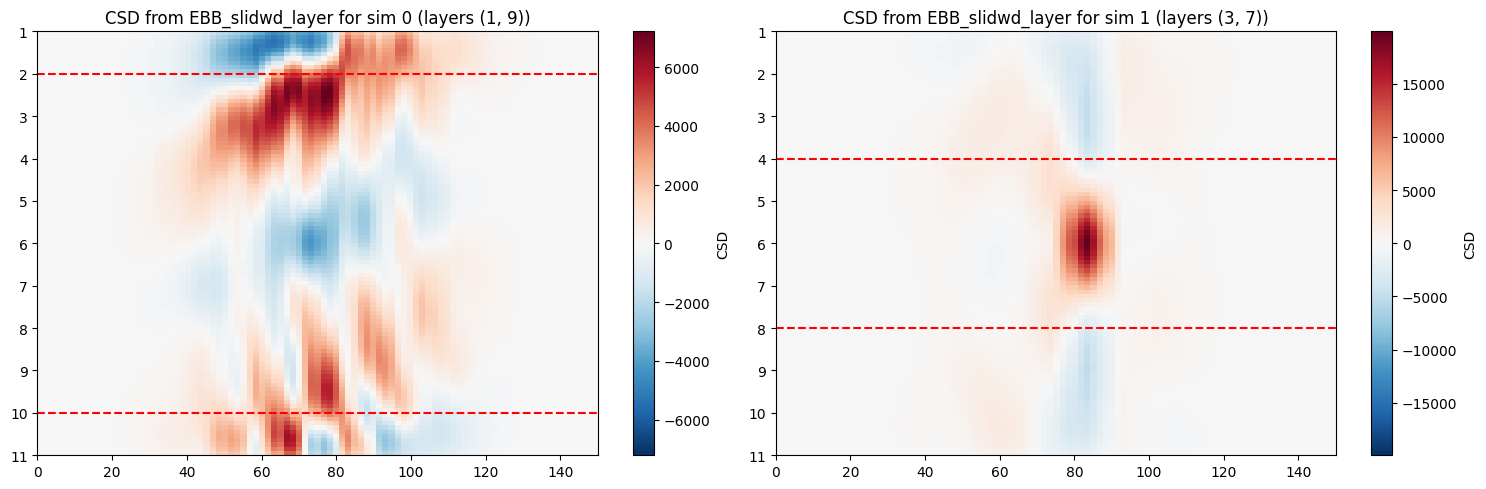

In [14]:
fig, ax = plt.subplots(1, csd_ebb_layer.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb_layer.shape[0]):
    plot_csd(csd_ebb_layer[sim_idx, :], data["time"], ax[sim_idx])
    ax[sim_idx].set_title(f'CSD from EBB_slidwd_layer for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')
    for layer in data["sim_layers"][sim_idx]:
        ax[sim_idx].axhline(layer/(n_layers-1), color='red', linestyle='--')